# Assignment 4: K-Means Clustering

In this assignment, you will use a dataset to perform K-means clustering, commonly used for grouping similar data points together. This task will involve several clear steps.

## Step 1: Prepare Your Dataset

- Choose a dataset good for grouping (such as the city lifestyle dataset)
- Clean up the dataset by removing any missing or unnecessary data
- Select only numeric columns for mathematical analysis
- Scale the data using StandardScaler to ensure all features are on the same scale

**Note:** Scaling is crucial for K-Means to work correctly since it's distance-based.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load data and select only the numeric columns for math
df = pd.read_csv('city_lifestyle_dataset.csv')
X = df.select_dtypes(include=['number'])

# Scale the data (Crucial for K-Means to work correctly)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Step 1 Complete: Data loaded and scaled.")

Step 1 Complete: Data loaded and scaled.


## Step 2: Visualize Data Before Clustering

Create a graph to show how your data looks before applying clustering. This helps you understand the raw data distribution and see what the data looks like normally.

We'll plot Air Quality vs Happiness Score to visualize the relationship between two key variables.

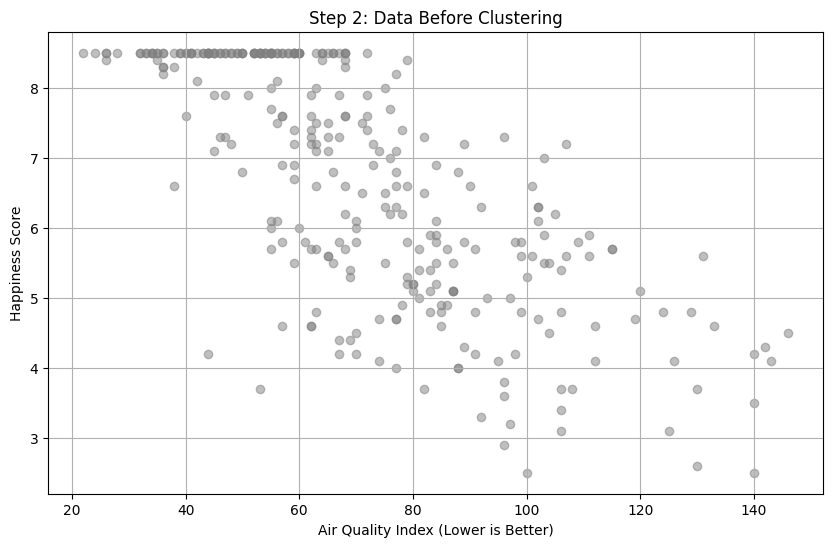

In [3]:
# Plot Air Quality vs Happiness to see the raw data distribution
plt.figure(figsize=(10, 6))
plt.scatter(df['air_quality_index'], df['happiness_score'], color='gray', alpha=0.5)
plt.title('Step 2: Data Before Clustering')
plt.xlabel('Air Quality Index (Lower is Better)')
plt.ylabel('Happiness Score')
plt.grid(True)
plt.show()

## Step 3: Implement K-means Clustering and Determine Optimal Clusters

Use the K-means algorithm to find groups in your data. To figure out the best number of groups, use the **Elbow Method**:
- Plot the within-cluster sum of squares (WCSS) against different numbers of clusters
- Look for the point where the line starts to flatten out (the "elbow" point)
- This indicates the optimal number of clusters for your data

**Elbow Method Process:**
1. Fit K-means models with cluster counts ranging from 1 to 10
2. Record the inertia (WCSS) for each model
3. Plot these values to identify where the decrease in WCSS becomes less significant

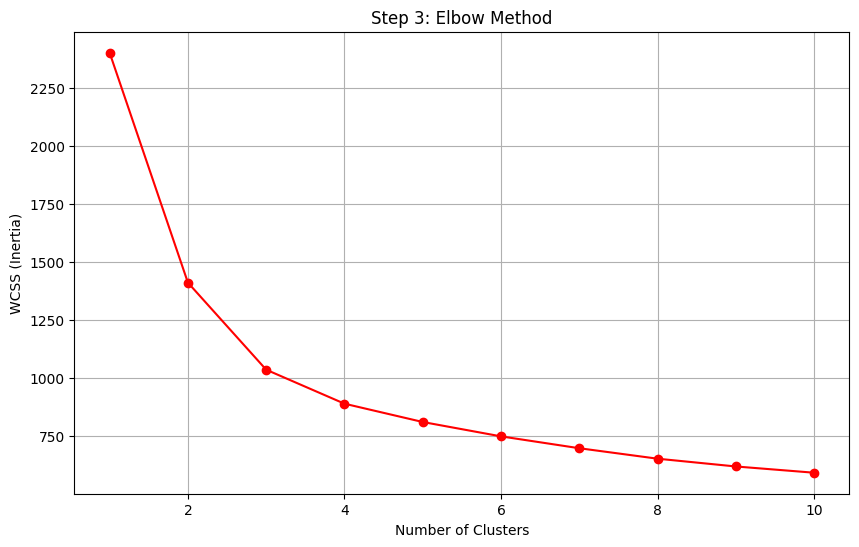

In [4]:
# Test cluster counts from 1 to 10 to find the best 'k'
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', color='red')
plt.title('Step 3: Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

## Step 4: Visualize Data After Clustering

Make another graph to show your data with the groups found by K-means. This visualization shows how the algorithm has organized the data into distinct clusters.

**Visualization Approach:**
1. Run the final K-means model with the optimal number of clusters (k=5 from the elbow method)
2. Use PCA (Principal Component Analysis) to project the high-dimensional data into 2D for easy visualization
3. Plot the clusters with different colors and mark the cluster centroids with red X marks

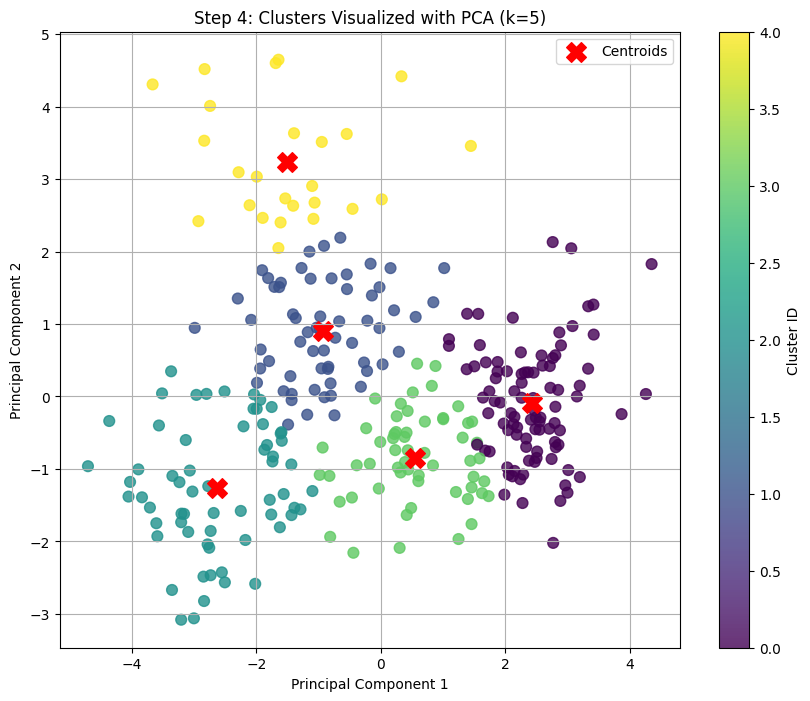

In [5]:
# 1. Run the final model with k=5 (based on the Elbow result)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 2. Use PCA to project 8 dimensions down to 2 for a clean plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Plot the distinct clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='viridis', s=60, alpha=0.8)

# Add centroids (red X marks)
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title(f'Step 4: Clusters Visualized with PCA (k={optimal_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.show()

## Step 5: Interpret Your Results

Explain what the results from the K-means clustering show about your data. Discuss how this information can help identify specific groups within the dataset.

**Analysis Points:**
- Average characteristics of each cluster
- Key differences between clusters
- Insights about which groups have similar properties
- Practical applications for these groupings (e.g., customer segmentation, city classification)

In [6]:
# Print the average stats for each group to name them
print("\nStep 5 Cluster Interpretation:")
print(df.groupby('cluster').mean(numeric_only=True))


Step 5 Cluster Interpretation:
         population_density   avg_income  internet_penetration     avg_rent  \
cluster                                                                       
0               2161.712766  4215.744681             90.278723  1509.042553   
1               6454.786885  2363.278689             71.962295   833.442623   
2               2722.285714  1220.793651             50.758730   420.793651   
3               2629.631579  2866.140351             76.592982  1021.754386   
4              10604.680000  2697.600000             74.084000   935.600000   

         air_quality_index  public_transport_score  happiness_score  \
cluster                                                               
0                50.936170               64.505319         8.386170   
1                86.131148               58.486885         5.934426   
2                79.952381               38.446032         4.600000   
3                58.859649               51.533333         